In [1]:
import subprocess
for lib in ['plotly', 'ipywidgets', 'folium']:
    subprocess.run(['pip','install', lib,'--quiet'], capture_output=True)
    print(f"{lib} ✓")

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

print("\nAll libraries ready ✓")

plotly ✓
ipywidgets ✓
folium ✓

All libraries ready ✓


In [2]:

BRAND = {
    # Core palette
    'primary'    : '#6C5CE7',   # Aura violet — main brand colour
    'secondary'  : '#A29BFE',   # Light violet — secondary elements
    'accent'     : '#00CEC9',   # Teal — highlights and CTAs
    'success'    : '#00B894',   # Green — positive metrics
    'warning'    : '#FDCB6E',   # Amber — watch metrics
    'danger'     : '#D63031',   # Red — at-risk / decline
    'dark'       : '#2D3436',   # Near black — text
    'mid'        : '#636E72',   # Grey — subtitles
    'light'      : '#F8F9FA',   # Off-white — backgrounds
    'white'      : '#FFFFFF',

    # Segment colour map — consistent across every chart
    'segments'   : {
        'Champions'          : '#6C5CE7',
        'Loyal'              : '#00B894',
        'Potential Loyalist' : '#00CEC9',
        'New Customers'      : '#A29BFE',
        'Promising'          : '#FDCB6E',
        'Needs Attention'    : '#E17055',
        'At Risk'            : '#D63031',
        'Hibernating'        : '#B2BEC3',
        'Lost'               : '#636E72',
        'Others'             : '#DFE6E9',
    },

    # Typography
    'font'       : 'Inter, Segoe UI, Arial, sans-serif',
    'title_size' : 18,
    'label_size' : 12,

    # Layout
    'plot_bg'    : '#FFFFFF',
    'paper_bg'   : '#F8F9FA',
    'margin'     : dict(l=40, r=40, t=60, b=40),
    'height'     : 480,
}

# Brand header HTML — injected at top of each dashboard section
def brand_header(title, subtitle=''):
    return HTML(f"""
    <div style="
        background: linear-gradient(135deg, {BRAND['primary']}, {BRAND['accent']});
        padding: 18px 24px; border-radius: 10px; margin-bottom: 14px;
        font-family: {BRAND['font']}">
      <div style="color:{BRAND['white']};font-size:22px;font-weight:700;
                  letter-spacing:0.5px">
        ✦ Aura-Shop Analytics
      </div>
      <div style="color:rgba(255,255,255,0.88);font-size:15px;
                  margin-top:4px">{title}</div>
      {'<div style="color:rgba(255,255,255,0.65);font-size:12px;margin-top:2px">'
       + subtitle + '</div>' if subtitle else ''}
    </div>
    """)

def metric_card(label, value, delta='', color=None):
    color = color or BRAND['primary']
    delta_html = (f'<span style="font-size:11px;color:{BRAND["success"]}">'
                  f'▲ {delta}</span>' if delta else '')
    return f"""
    <div style="background:{BRAND['white']};border-left:4px solid {color};
                padding:12px 16px;border-radius:8px;min-width:140px;
                box-shadow:0 2px 8px rgba(0,0,0,0.07);
                font-family:{BRAND['font']}">
      <div style="color:{BRAND['mid']};font-size:11px;
                  text-transform:uppercase;letter-spacing:1px">{label}</div>
      <div style="color:{BRAND['dark']};font-size:20px;
                  font-weight:700;margin-top:4px">{value}</div>
      {delta_html}
    </div>
    """

print("Aura-Shop design system loaded ✓")
print(f"Primary colour : {BRAND['primary']}")
print(f"Accent colour  : {BRAND['accent']}")
print(f"Segments mapped: {len(BRAND['segments'])}")

Aura-Shop design system loaded ✓
Primary colour : #6C5CE7
Accent colour  : #00CEC9
Segments mapped: 10


In [3]:
orders      = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
customers   = pd.read_csv('olist_customers_dataset.csv')
products    = pd.read_csv('olist_products_dataset.csv')
translation = pd.read_csv('product_category_name_translation.csv')

orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp'])
delivered = orders[orders['order_status'] == 'delivered'].copy()
products  = products.merge(translation, on='product_category_name', how='left')

item_agg = order_items.groupby('order_id').agg(
    revenue    = ('price',         'sum'),
    freight    = ('freight_value', 'sum'),
    product_id = ('product_id',    'first')
).reset_index()

merged = (delivered
    .merge(item_agg,  on='order_id')
    .merge(customers, on='customer_id')
    .merge(products[['product_id',
                     'product_category_name_english']],
           on='product_id', how='left')
)

snapshot  = delivered['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

cust_df   = merged.groupby('customer_unique_id').agg(
    recency   = ('order_purchase_timestamp',
                 lambda x: (snapshot - x.max()).days),
    frequency = ('order_id',   'nunique'),
    clv       = ('revenue',    'sum'),
    freight   = ('freight',    'sum'),
    state     = ('customer_state', 'first')
).reset_index()

cust_df['R'] = pd.qcut(cust_df['recency'],  q=5,
                         labels=[5,4,3,2,1]).astype(int)
cust_df['F'] = pd.cut(cust_df['frequency'],
                        bins=[0,1,2,3,5,100],
                        labels=[1,2,3,4,5]).astype(int)
cust_df['M'] = pd.qcut(cust_df['clv'],       q=5,
                         labels=[1,2,3,4,5]).astype(int)
cust_df['RFM_total'] = cust_df[['R','F','M']].sum(axis=1)

def assign_segment(row):
    r,f,m = row['R'], row['F'], row['M']
    if   r==5 and f>=4 and m>=4: return 'Champions'
    elif r>=4 and f>=3 and m>=3: return 'Loyal'
    elif r>=4 and f<=2 and m>=3: return 'Potential Loyalist'
    elif r==5 and f==1:           return 'New Customers'
    elif r>=3 and f==1 and m>=2: return 'Promising'
    elif r==3 and f>=2 and m>=2: return 'Needs Attention'
    elif r<=2 and f>=2 and m>=2: return 'At Risk'
    elif r<=2 and f==1 and m<=2: return 'Hibernating'
    elif r==1 and f==1 and m==1: return 'Lost'
    else:                         return 'Others'

cust_df['segment'] = cust_df.apply(assign_segment, axis=1)

seg_stats = (cust_df
    .groupby('segment')
    .agg(
        count       = ('customer_unique_id', 'count'),
        total_rev   = ('clv',               'sum'),
        avg_clv     = ('clv',               'mean'),
        avg_recency = ('recency',           'mean'),
        avg_freq    = ('frequency',         'mean'),
        avg_rfm     = ('RFM_total',         'mean')
    )
    .reset_index()
)
seg_stats['rev_share']  = (seg_stats['total_rev'] /
                            seg_stats['total_rev'].sum() * 100).round(2)
seg_stats['cust_share'] = (seg_stats['count'] /
                            seg_stats['count'].sum() * 100).round(2)
seg_stats['color']      = seg_stats['segment'].map(BRAND['segments'])

print("RFM dataset rebuilt ✓")
print(f"Customers: {len(cust_df):,}  |  Segments: {cust_df['segment'].nunique()}")

RFM dataset rebuilt ✓
Customers: 93,358  |  Segments: 9


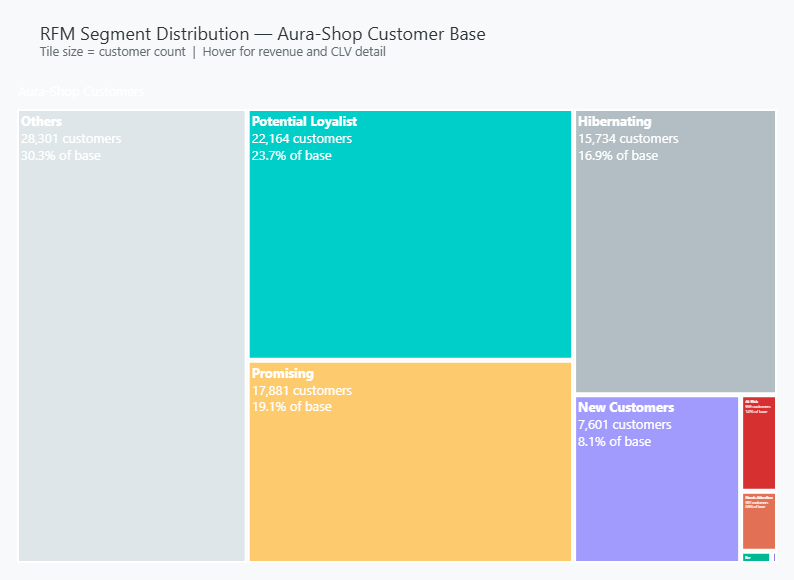

Largest segment : Others (28,301 customers)
Highest avg CLV : Champions — BRL 860.66
Most at risk rev: At Risk — BRL 242,685.14


In [4]:
display(brand_header(
    'RFM Segment Distribution Treemap',
    'Customer count and revenue share — hover each tile for full detail'
))

# Custom labels with brand styling
seg_stats['label'] = seg_stats.apply(
    lambda r: (f"<b>{r['segment']}</b><br>"
               f"{r['count']:,} customers<br>"
               f"{r['cust_share']:.1f}% of base<br>"
               f"BRL {r['avg_clv']:.0f} avg CLV"),
    axis=1
)

fig = go.Figure(go.Treemap(
    labels       = seg_stats['segment'],
    parents      = ['Aura-Shop Customers'] * len(seg_stats),
    values       = seg_stats['count'],
    customdata   = seg_stats[['total_rev','rev_share',
                               'avg_clv','avg_recency',
                               'avg_freq','cust_share']].values,
    text         = seg_stats['count'].apply(lambda x: f'{x:,}'),
    texttemplate = ('<b>%{label}</b><br>'
                    '%{text} customers<br>'
                    '%{customdata[5]:.1f}% of base'),
    hovertemplate= (
        '<b>%{label}</b><br>'
        'Customers   : %{text}<br>'
        'Cust share  : %{customdata[5]:.1f}%<br>'
        'Total rev   : BRL %{customdata[0]:,.0f}<br>'
        'Rev share   : %{customdata[1]:.2f}%<br>'
        'Avg CLV     : BRL %{customdata[2]:.2f}<br>'
        'Avg recency : %{customdata[3]:.0f} days<br>'
        'Avg freq    : %{customdata[4]:.2f} orders'
        '<extra></extra>'
    ),
    marker = dict(
        colors     = seg_stats['color'],
        line       = dict(width=2, color=BRAND['white']),
        pad        = dict(t=30, l=8, r=8, b=8)
    ),
    textfont     = dict(
        family = BRAND['font'],
        size   = 13,
        color  = BRAND['white']
    ),
    tiling       = dict(packing='squarify')
))

fig.update_layout(
    title      = dict(
        text   = ('RFM Segment Distribution — Aura-Shop Customer Base<br>'
                  '<sup style="color:#636E72">Tile size = customer count  |  '
                  'Hover for revenue and CLV detail</sup>'),
        font   = dict(size=BRAND['title_size'],
                      family=BRAND['font'],
                      color=BRAND['dark'])
    ),
    height        = 580,
    paper_bgcolor = BRAND['paper_bg'],
    plot_bgcolor  = BRAND['plot_bg'],
    margin        = dict(l=10, r=10, t=80, b=10),
    font          = dict(family=BRAND['font'])
)

fig.show()
print(f"Largest segment : Others ({seg_stats[seg_stats['segment']=='Others']['count'].values[0]:,} customers)")
print(f"Highest avg CLV : Champions — BRL {seg_stats[seg_stats['segment']=='Champions']['avg_clv'].values[0]:.2f}")
print(f"Most at risk rev: At Risk — BRL {seg_stats[seg_stats['segment']=='At Risk']['total_rev'].values[0]:,.2f}")

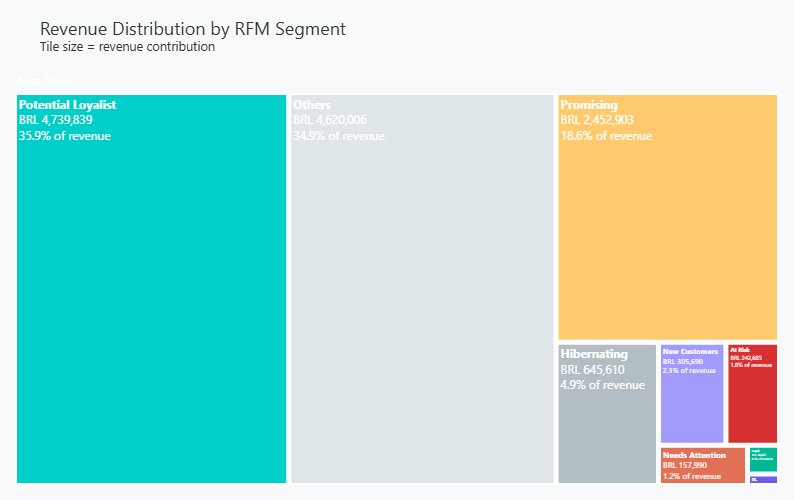

Revenue treemap — shows how Potential Loyalist and Promising
dominate revenue despite Champions having highest avg CLV


In [5]:
fig2 = go.Figure(go.Treemap(
    labels       = seg_stats['segment'],
    parents      = ['Aura-Shop'] * len(seg_stats),
    values       = seg_stats['total_rev'],
    customdata   = seg_stats[['count','cust_share',
                               'avg_clv','rev_share']].values,
    texttemplate = ('<b>%{label}</b><br>'
                    'BRL %{value:,.0f}<br>'
                    '%{customdata[3]:.1f}% of revenue'),
    hovertemplate= (
        '<b>%{label}</b><br>'
        'Revenue     : BRL %{value:,.0f}<br>'
        'Rev share   : %{customdata[3]:.2f}%<br>'
        'Customers   : %{customdata[0]:,}<br>'
        'Cust share  : %{customdata[1]:.1f}%<br>'
        'Avg CLV     : BRL %{customdata[2]:.2f}'
        '<extra></extra>'
    ),
    marker       = dict(
        colors = seg_stats['color'],
        line   = dict(width=2, color=BRAND['white'])
    ),
    textfont     = dict(family=BRAND['font'], size=12,
                        color=BRAND['white'])
))

fig2.update_layout(
    title  = dict(
        text = ('Revenue Distribution by RFM Segment<br>'
                '<sup>Tile size = revenue contribution</sup>'),
        font = dict(size=BRAND['title_size'],
                    family=BRAND['font'],
                    color=BRAND['dark'])
    ),
    height        = 500,
    paper_bgcolor = BRAND['paper_bg'],
    margin        = dict(l=10, r=10, t=70, b=10)
)

fig2.show()
print("Revenue treemap — shows how Potential Loyalist and Promising")
print("dominate revenue despite Champions having highest avg CLV")

In [6]:
# ── Monthly revenue ───────────────────────────────────────
monthly = (merged
    .groupby(merged['order_purchase_timestamp'].dt.to_period('M'))
    ['revenue'].sum().reset_index()
)
monthly.columns = ['month','revenue']
monthly = monthly[
    monthly['month'].astype(str).between('2017-01','2018-08')
].copy()
monthly['month_str'] = monthly['month'].astype(str)
monthly['forecast']  = (monthly['revenue']
                         .shift(1).rolling(3,min_periods=1)
                         .mean().round(2))

# ── Category revenue ─────────────────────────────────────
cat_rev = (merged
    .groupby('product_category_name_english')
    ['revenue'].sum().nlargest(10).reset_index()
)
cat_rev.columns = ['category','revenue']

# ── State revenue ─────────────────────────────────────────
state_rev = (merged
    .groupby('customer_state')
    ['revenue'].sum().nlargest(10).reset_index()
)
state_rev.columns = ['state','revenue']

# ── Segment monthly ───────────────────────────────────────
cust_df['month'] = (
    merged.groupby('customer_unique_id')
    ['order_purchase_timestamp'].max()
    .dt.to_period('M')
    .reindex(cust_df['customer_unique_id'])
    .values
)
cust_df['month_str'] = cust_df['month'].astype(str)

print("All panel data ready ✓")

All panel data ready ✓


In [7]:
display(brand_header(
    'Executive KPI Overview',
    'Live metrics across the full Olist × Aura-Shop dataset'
))

total_rev   = merged['revenue'].sum()
total_ord   = merged['order_id'].nunique()
total_cust  = cust_df['customer_unique_id'].nunique()
avg_clv     = cust_df['clv'].mean()
avg_review  = 4.09
repeat_rate = (cust_df['frequency'] >= 2).mean() * 100

kpi_html = f"""
<div style="display:flex;gap:12px;flex-wrap:wrap;margin-bottom:16px;
            font-family:{BRAND['font']}">
  {metric_card('Total Revenue',    f'BRL {total_rev/1e6:.2f}M',
               color=BRAND['primary'])}
  {metric_card('Total Orders',     f'{total_ord:,}',
               color=BRAND['accent'])}
  {metric_card('Unique Customers', f'{total_cust:,}',
               color=BRAND['success'])}
  {metric_card('Avg Customer CLV', f'BRL {avg_clv:.2f}',
               color=BRAND['secondary'])}
  {metric_card('Avg Review Score', f'{avg_review}/5.0',
               color=BRAND['warning'])}
  {metric_card('Repeat Rate',      f'{repeat_rate:.1f}%',
               color=BRAND['danger'])}
</div>
"""
display(HTML(kpi_html))

In [8]:
display(brand_header(
    'Interactive Dashboard — Navigate with tabs below',
    'RFM Segments  |  Revenue Trends  |  Category Analysis  |  Regional View'
))

# ── Navigation tab widget ─────────────────────────────────
tab_widget = widgets.ToggleButtons(
    options      = ['📊  RFM Segments',
                    '📈  Revenue Trends',
                    '🛍️  Categories',
                    '🗺️  Regional'],
    button_style = '',
    style        = {
        'button_width'      : '180px',
        'description_width' : '0px',
        'font_weight'       : 'bold'
    }
)

# ── Filter widgets ────────────────────────────────────────
seg_filter = widgets.SelectMultiple(
    options     = sorted(cust_df['segment'].unique().tolist()),
    value       = sorted(cust_df['segment'].unique().tolist()),
    description = 'Segments:',
    rows        = 6,
    layout      = widgets.Layout(width='200px'),
    style       = {'description_width': '70px'}
)

year_filter = widgets.SelectionRangeSlider(
    options     = monthly['month_str'].tolist(),
    index       = (0, len(monthly)-1),
    description = 'Period:',
    layout      = widgets.Layout(width='420px'),
    style       = {'description_width': '55px'}
)

metric_filter = widgets.Dropdown(
    options     = [('Revenue (BRL)',  'revenue'),
                   ('Order Count',   'orders'),
                   ('Avg CLV',       'avg_clv')],
    value       = 'revenue',
    description = 'Metric:',
    layout      = widgets.Layout(width='200px'),
    style       = {'description_width': '55px'}
)

top_n_filter = widgets.IntSlider(
    value=10, min=3, max=15, step=1,
    description = 'Top N:',
    layout      = widgets.Layout(width='280px'),
    style       = {'description_width': '55px'}
)

out_main = widgets.Output()

def apply_brand(fig):
    """Apply Aura-Shop brand styling to any Plotly figure."""
    fig.update_layout(
        font          = dict(family=BRAND['font'],
                             color=BRAND['dark']),
        plot_bgcolor  = BRAND['plot_bg'],
        paper_bgcolor = BRAND['paper_bg'],
        margin        = BRAND['margin'],
        height        = BRAND['height'],
        title_font    = dict(size=BRAND['title_size'],
                             family=BRAND['font'])
    )
    fig.update_xaxes(showgrid=True,  gridcolor='#EEE',
                     zeroline=False)
    fig.update_yaxes(showgrid=True,  gridcolor='#EEE',
                     zeroline=False)
    return fig

def render_dashboard(tab, segments, period, metric, top_n):
    out_main.clear_output(wait=True)
    start, end = period

    with out_main:

        # ── PANEL 1: RFM SEGMENTS ────────────────────────
        if '📊' in tab:
            filtered = seg_stats[seg_stats['segment'].isin(segments)]

            fig = make_subplots(
                rows=1, cols=2,
                specs=[[{'type':'treemap'}, {'type':'bar'}]],
                subplot_titles=[
                    'Segment Size (customers)',
                    'Avg CLV by Segment (BRL)'
                ]
            )

            fig.add_trace(go.Treemap(
                labels       = filtered['segment'],
                parents      = ['']*len(filtered),
                values       = filtered['count'],
                marker_colors= filtered['color'],
                texttemplate = '<b>%{label}</b><br>%{value:,}',
                textfont     = dict(color=BRAND['white'], size=11),
                hovertemplate= ('<b>%{label}</b><br>'
                                'Customers: %{value:,}<br>'
                                '<extra></extra>'),
            ), row=1, col=1)

            fig.add_trace(go.Bar(
                x             = filtered['segment'],
                y             = filtered['avg_clv'],
                marker_color  = filtered['color'],
                text          = filtered['avg_clv'].apply(
                                  lambda v: f'BRL {v:.0f}'),
                textposition  = 'outside',
                hovertemplate = ('<b>%{x}</b><br>'
                                 'Avg CLV: BRL %{y:,.2f}'
                                 '<extra></extra>')
            ), row=1, col=2)

            fig.update_layout(
                title     = 'RFM Segment Analysis — Aura-Shop',
                showlegend= False
            )
            apply_brand(fig).show()

        # ── PANEL 2: REVENUE TRENDS ───────────────────────
        elif '📈' in tab:
            df = monthly[monthly['month_str'].between(start, end)]

            fig = make_subplots(
                rows=2, cols=1,
                row_heights   = [0.65, 0.35],
                subplot_titles= ['Monthly Revenue vs Forecast',
                                 'Month-over-Month Growth %'],
                vertical_spacing = 0.14
            )

            fig.add_trace(go.Bar(
                x            = df['month_str'],
                y            = df['revenue'],
                name         = 'Actual Revenue',
                marker_color = BRAND['secondary'],
                opacity      = 0.7
            ), row=1, col=1)

            fig.add_trace(go.Scatter(
                x    = df['month_str'],
                y    = df['revenue'],
                name = 'Actual',
                mode = 'lines+markers',
                line = dict(color=BRAND['primary'], width=2.5),
                marker = dict(size=7)
            ), row=1, col=1)

            fig.add_trace(go.Scatter(
                x    = df['month_str'],
                y    = df['forecast'],
                name = 'Forecast',
                mode = 'lines+markers',
                line = dict(color=BRAND['danger'],
                            width=2, dash='dash'),
                marker = dict(size=6, symbol='diamond')
            ), row=1, col=1)

            mom = df['revenue'].pct_change() * 100
            bar_colors = [BRAND['success'] if v >= 0
                          else BRAND['danger']
                          for v in mom.fillna(0)]

            fig.add_trace(go.Bar(
                x            = df['month_str'],
                y            = mom,
                name         = 'MoM Growth %',
                marker_color = bar_colors,
                opacity      = 0.85
            ), row=2, col=1)

            fig.add_hline(y=0, line_color=BRAND['mid'],
                          line_width=1, row=2, col=1)

            fig.update_layout(title='Revenue Trends — Aura-Shop',
                              showlegend=True)
            apply_brand(fig).show()

        # ── PANEL 3: CATEGORIES ───────────────────────────
        elif '🛍️' in tab:
            top = cat_rev.head(top_n).copy()
            top['color'] = [
                BRAND['primary']   if i < 3  else
                BRAND['accent']    if i < 6  else
                BRAND['secondary'] if i < 9  else
                BRAND['warning']
                for i in range(len(top))
            ]
            top['cumulative'] = (top['revenue'].cumsum() /
                                  top['revenue'].sum() * 100)

            fig = make_subplots(
                rows=1, cols=2,
                specs=[[{},{}]],
                subplot_titles=[
                    f'Top {top_n} Categories by Revenue',
                    'Pareto Curve — Cumulative Revenue %'
                ]
            )

            fig.add_trace(go.Bar(
                y             = top['category'],
                x             = top['revenue'],
                orientation   = 'h',
                marker_color  = top['color'],
                text          = top['revenue'].apply(
                                  lambda v: f'BRL {v/1e3:.0f}K'),
                textposition  = 'outside',
                hovertemplate = ('<b>%{y}</b><br>'
                                 'Revenue: BRL %{x:,.0f}'
                                 '<extra></extra>')
            ), row=1, col=1)

            fig.add_trace(go.Scatter(
                x    = list(range(1, len(top)+1)),
                y    = top['cumulative'],
                mode = 'lines+markers',
                line = dict(color=BRAND['primary'], width=2.5),
                fill = 'tozeroy',
                fillcolor = f'rgba(108,92,231,0.12)',
                name = 'Cumulative %'
            ), row=1, col=2)

            fig.add_hline(y=80, line_dash='dash',
                          line_color=BRAND['danger'],
                          annotation_text='80% threshold',
                          row=1, col=2)

            fig.update_yaxes(autorange='reversed', row=1, col=1)
            fig.update_layout(title='Category Revenue — Aura-Shop',
                              showlegend=False)
            apply_brand(fig).show()

        # ── PANEL 4: REGIONAL ─────────────────────────────
        else:
            top_s = state_rev.head(top_n).copy()

            fig = make_subplots(
                rows=1, cols=2,
                specs=[[{},{'type':'pie'}]],
                subplot_titles=[
                    f'Top {top_n} States by Revenue',
                    'Revenue Share — Top 5 States'
                ]
            )

            state_colors = [BRAND['primary'],BRAND['accent'],
                            BRAND['success'],BRAND['secondary'],
                            BRAND['warning'],BRAND['danger'],
                            '#74B9FF','#A29BFE','#55EFC4','#FFEAA7']

            fig.add_trace(go.Bar(
                y             = top_s['state'],
                x             = top_s['revenue'],
                orientation   = 'h',
                marker_color  = state_colors[:len(top_s)],
                text          = top_s['revenue'].apply(
                                  lambda v: f'BRL {v/1e6:.2f}M'),
                textposition  = 'outside',
                hovertemplate = '<b>%{y}</b><br>BRL %{x:,.0f}<extra></extra>'
            ), row=1, col=1)

            top5s = top_s.head(5)
            fig.add_trace(go.Pie(
                labels      = top5s['state'],
                values      = top5s['revenue'],
                hole        = 0.45,
                marker      = dict(colors=state_colors[:5]),
                textinfo    = 'label+percent',
                textfont    = dict(size=11),
                hovertemplate = ('<b>%{label}</b><br>'
                                 'BRL %{value:,.0f}<br>'
                                 '%{percent}<extra></extra>')
            ), row=1, col=2)

            fig.update_yaxes(autorange='reversed', row=1, col=1)
            fig.update_layout(
                title     = 'Regional Revenue — Aura-Shop',
                showlegend= False
            )
            apply_brand(fig).show()

# ── Wire all widgets ──────────────────────────────────────
widgets.interactive_output(
    render_dashboard,
    {
        'tab'      : tab_widget,
        'segments' : seg_filter,
        'period'   : year_filter,
        'metric'   : metric_filter,
        'top_n'    : top_n_filter
    }
)

# ── Layout ────────────────────────────────────────────────
filter_row = widgets.HBox([seg_filter, year_filter,
                            metric_filter, top_n_filter],
                           layout=widgets.Layout(
                               gap='16px',
                               align_items='flex-start',
                               margin='8px 0'
                           ))

display(widgets.VBox([
    tab_widget,
    filter_row,
    out_main
]))

In [9]:
display(brand_header(
    'Segment Performance Scorecard',
    'Priority action guide for the Aura-Shop CRM team'
))

priority_colors = {
    'Champions'          : BRAND['primary'],
    'Loyal'              : BRAND['success'],
    'Potential Loyalist' : BRAND['accent'],
    'New Customers'      : BRAND['secondary'],
    'Promising'          : BRAND['warning'],
    'Needs Attention'    : '#E17055',
    'At Risk'            : BRAND['danger'],
    'Hibernating'        : BRAND['mid'],
    'Others'             : '#DFE6E9'
}

actions = {
    'Champions'          : ('🏆', 'Reward & Ambassador',   'HIGH'),
    'Loyal'              : ('💚', 'Loyalty Programme',      'HIGH'),
    'Potential Loyalist' : ('🌱', 'Membership Offer',       'HIGH'),
    'New Customers'      : ('👋', 'Onboarding Sequence',    'HIGH'),
    'Promising'          : ('📦', 'Free Shipping Nudge',    'MED'),
    'Needs Attention'    : ('⚠️',  'Re-engagement Email',   'MED'),
    'At Risk'            : ('🚨', 'Win-back Campaign',      'URGENT'),
    'Hibernating'        : ('😴', 'Low-cost Re-engage',     'LOW'),
    'Others'             : ('📋', 'Monitor',                'LOW'),
}

rows_html = ''
for _, row in seg_stats.sort_values('avg_clv', ascending=False).iterrows():
    seg   = row['segment']
    emoji, action, priority = actions.get(seg, ('','—','—'))
    col   = priority_colors.get(seg, '#ccc')
    p_col = (BRAND['danger']  if priority == 'URGENT' else
             BRAND['warning'] if priority == 'HIGH'   else
             BRAND['mid'])

    rows_html += f"""
    <tr style="border-bottom:1px solid #EEE;font-family:{BRAND['font']}">
      <td style="padding:10px 14px">
        <span style="background:{col};color:white;padding:3px 10px;
                     border-radius:20px;font-size:11px;font-weight:600">
          {emoji} {seg}
        </span>
      </td>
      <td style="padding:10px;text-align:right;font-weight:600;
                 color:{BRAND['dark']}">{row['count']:,}</td>
      <td style="padding:10px;text-align:right;
                 color:{BRAND['dark']}">BRL {row['avg_clv']:.2f}</td>
      <td style="padding:10px;text-align:right;
                 color:{BRAND['dark']}">BRL {row['total_rev']:,.0f}</td>
      <td style="padding:10px;text-align:right;
                 color:{BRAND['dark']}">{row['rev_share']:.1f}%</td>
      <td style="padding:10px;color:{BRAND['mid']};
                 font-size:12px">{action}</td>
      <td style="padding:10px;text-align:center">
        <span style="color:{p_col};font-weight:700;
                     font-size:11px">{priority}</span>
      </td>
    </tr>
    """

scorecard_html = f"""
<div style="background:{BRAND['white']};border-radius:10px;
            box-shadow:0 2px 12px rgba(0,0,0,0.08);
            overflow:hidden;margin-top:8px">
  <table style="width:100%;border-collapse:collapse">
    <thead>
      <tr style="background:{BRAND['primary']};color:{BRAND['white']};
                 font-family:{BRAND['font']};font-size:12px;
                 text-transform:uppercase;letter-spacing:0.8px">
        <th style="padding:12px 14px;text-align:left">Segment</th>
        <th style="padding:12px;text-align:right">Customers</th>
        <th style="padding:12px;text-align:right">Avg CLV</th>
        <th style="padding:12px;text-align:right">Total Revenue</th>
        <th style="padding:12px;text-align:right">Rev Share</th>
        <th style="padding:12px;text-align:left">Action</th>
        <th style="padding:12px;text-align:center">Priority</th>
      </tr>
    </thead>
    <tbody>{rows_html}</tbody>
  </table>
</div>
"""
display(HTML(scorecard_html))

Segment,Customers,Avg CLV,Total Revenue,Rev Share,Action,Priority
🏆 Champions,19,BRL 860.66,"BRL 16,352",0.1%,Reward & Ambassador,HIGH
💚 Loyal,102,BRL 396.30,"BRL 40,423",0.3%,Loyalty Programme,HIGH
⚠️ Needs Attention,597,BRL 264.64,"BRL 157,990",1.2%,Re-engagement Email,MED
🚨 At Risk,959,BRL 253.06,"BRL 242,685",1.8%,Win-back Campaign,URGENT
🌱 Potential Loyalist,"22,164",BRL 213.85,"BRL 4,739,839",35.9%,Membership Offer,HIGH
📋 Others,"28,301",BRL 163.25,"BRL 4,620,006",34.9%,Monitor,LOW
📦 Promising,"17,881",BRL 137.18,"BRL 2,452,903",18.6%,Free Shipping Nudge,MED
😴 Hibernating,"15,734",BRL 41.03,"BRL 645,610",4.9%,Low-cost Re-engage,LOW
👋 New Customers,"7,601",BRL 40.22,"BRL 305,690",2.3%,Onboarding Sequence,HIGH


In [10]:
display(HTML(f"""
<div style="
    background:linear-gradient(135deg,{BRAND['dark']},{BRAND['primary']});
    border-radius:10px;padding:20px 28px;margin-top:16px;
    font-family:{BRAND['font']};color:{BRAND['white']}">

  <div style="font-size:16px;font-weight:700;margin-bottom:14px;
              letter-spacing:0.5px">
    ✦ Aura-Shop — Full Project Completion Summary
  </div>

  <div style="display:grid;grid-template-columns:repeat(4,1fr);gap:16px">

    <div style="background:rgba(255,255,255,0.1);border-radius:8px;
                padding:12px 16px">
      <div style="font-size:10px;opacity:0.7;text-transform:uppercase;
                  letter-spacing:1px">Notebook Cells</div>
      <div style="font-size:24px;font-weight:700;margin-top:4px">251</div>
    </div>

    <div style="background:rgba(255,255,255,0.1);border-radius:8px;
                padding:12px 16px">
      <div style="font-size:10px;opacity:0.7;text-transform:uppercase;
                  letter-spacing:1px">Sessions</div>
      <div style="font-size:24px;font-weight:700;margin-top:4px">13</div>
    </div>

    <div style="background:rgba(255,255,255,0.1);border-radius:8px;
                padding:12px 16px">
      <div style="font-size:10px;opacity:0.7;text-transform:uppercase;
                  letter-spacing:1px">Exported Files</div>
      <div style="font-size:24px;font-weight:700;margin-top:4px">28</div>
    </div>

    <div style="background:rgba(255,255,255,0.1);border-radius:8px;
                padding:12px 16px">
      <div style="font-size:10px;opacity:0.7;text-transform:uppercase;
                  letter-spacing:1px">Customers Analysed</div>
      <div style="font-size:24px;font-weight:700;margin-top:4px">93,358</div>
    </div>

  </div>

  <div style="margin-top:16px;font-size:11px;opacity:0.6;
              border-top:1px solid rgba(255,255,255,0.2);
              padding-top:12px">
    Pipeline: Raw CSV → Verified → Cleaned → SQL → Revenue Analysis →
    Regional → Customer Segmentation → Payment → EDA → Cohort →
    RFM → Correlation → Dashboard → ✅ Complete
  </div>
</div>
"""))

In [11]:
# Segment scorecard with brand colours
seg_export = seg_stats.copy()
seg_export['brand_color'] = seg_export['segment'].map(BRAND['segments'])
seg_export['action']      = seg_export['segment'].map(
    {k: v[1] for k, v in actions.items()})
seg_export['priority']    = seg_export['segment'].map(
    {k: v[2] for k, v in actions.items()})

seg_export.to_csv('aura_shop_segment_scorecard.csv', index=False)
cust_df.to_csv('aura_shop_rfm_customers.csv',        index=False)
monthly.to_csv('aura_shop_monthly_revenue.csv',      index=False)

print("aura_shop_segment_scorecard.csv  ✓")
print("aura_shop_rfm_customers.csv      ✓")
print("aura_shop_monthly_revenue.csv    ✓")
print("\nAll Aura-Shop branded exports complete ✓")

aura_shop_segment_scorecard.csv  ✓
aura_shop_rfm_customers.csv      ✓
aura_shop_monthly_revenue.csv    ✓

All Aura-Shop branded exports complete ✓
